# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2025**


----

# Trabajo práctico entregable - parte 2


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
sns.set_context('talk')

# importamos lo necesario de sklearn
from sklearn.preprocessing import OneHotEncoder

In [3]:
# Acá deberían leer el conjunto de datos que ya tienen.
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Aplicar una codificación One-hot encoding a cada fila, para las variables categóricas. Si lo consideran necesario, pueden volver a reducir el número de categorías únicas.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


In [6]:
# Comenzamos viendo el dataframe pero eliminando las columnas BuildingArea y YearBuilt
melb_df_filtered = melb_df.drop(columns=["BuildingArea", "YearBuilt"])
melb_df_filtered.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
2131,Doncaster,1a Morris St,4,h,1152000.0,S,Jellis,6/08/2016,13.9,3108.0,4.0,2.0,2.0,336.0,Manningham,-37.7940,145.1178,Eastern Metropolitan,9028.0
7319,Glen Huntly,201/1177 Glen Huntly Rd,2,u,445000.0,S,Woodards,24/09/2016,10.4,3163.0,2.0,1.0,1.0,0.0,Glen Eira,-37.8894,145.0431,Southern Metropolitan,2403.0
3086,Hampton,10 Talbot St,4,h,2800000.0,VB,RT,27/06/2016,13.7,3188.0,4.0,3.0,2.0,1093.0,Bayside,-37.9345,145.0000,Southern Metropolitan,5454.0
6559,Williamstown North,12/29 Champion Rd,2,u,380000.0,PI,Greg,18/06/2016,8.9,3016.0,2.0,1.0,1.0,0.0,Hobsons Bay,-37.8564,144.8864,Western Metropolitan,802.0
8046,Kingsville,87 Chirnside St,3,h,1190000.0,SP,Village,13/05/2017,7.8,3012.0,3.0,1.0,1.0,276.0,Maribyrnong,-37.8082,144.8828,Western Metropolitan,1808.0


In [4]:
# Veamos ahora las columnas de este dataframe
melb_df_filtered.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname',
       'Propertycount'],
      dtype='object')

In [5]:
# Veamos ahora las que tengan valores nulos
melb_df_filtered.isnull().sum()[melb_df_filtered.isnull().sum()>0]

Car              62
CouncilArea    1369
dtype: int64

In [6]:
# IMPUTAR EL COUNCIL AREA?

In [7]:
# Ahora apliquemos una codificación One-hot encoding a cada fila, para las 
# variables categóricas, que son:
columnas_categoricas = ["Suburb", "Type", "Method", "SellerG", "CouncilArea",
                        "Regionname"]

Notemos que no utilizamos "Address" como columna categórica ya que al ser la dirección del lugar, van a ser distintas para todos. Por lo tanto, al hacer el encoding estaríamos agregando muchas columnas sobre algo que probablemente no nos de mucha información. Para la fecha sucede algo similar. Lo que podemos hacer entonces es eliminar estas 2 columnas.

In [8]:
melb_df_filtered = melb_df_filtered.drop(columns=["Address", "Date"])
melb_df_filtered

,Suburb,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,2,h,1480000.0,S,Biggin,2.5,3067.0,2.0,1.0,1.0,202.0,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,2,h,1035000.0,S,Biggin,2.5,3067.0,2.0,1.0,0.0,156.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,3,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,2.0,0.0,134.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,3,h,850000.0,PI,Biggin,2.5,3067.0,3.0,2.0,1.0,94.0,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,4,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,1.0,2.0,120.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,4,h,1245000.0,S,Barry,16.7,3150.0,4.0,2.0,2.0,652.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,3,h,1031000.0,SP,Williams,6.8,3016.0,3.0,2.0,2.0,333.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,3,h,1170000.0,S,Raine,6.8,3016.0,3.0,2.0,4.0,436.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,4,h,2500000.0,PI,Sweeney,6.8,3016.0,4.0,1.0,5.0,866.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


In [9]:
# Veamos ahora cuantas categorías hay en cada columna
for col in columnas_categoricas:
    print(f"{col}: {melb_df_filtered[col].nunique()} categorías únicas")
# y la frecuencia de cada categoría
for col in columnas_categoricas:
    print(f"\n{col}:")
    print(melb_df_filtered[col].value_counts())

Suburb: 314 categorías únicas
Type: 3 categorías únicas
Method: 5 categorías únicas
SellerG: 268 categorías únicas
CouncilArea: 33 categorías únicas
Regionname: 8 categorías únicas

Suburb:
Suburb
Reservoir         359
Richmond          260
Bentleigh East    249
Preston           239
Brunswick         222
                 ... 
Sandhurst           1
Bullengarook        1
Croydon South       1
Montrose            1
Monbulk             1
Name: count, Length: 314, dtype: int64

Type:
Type
h    9449
u    3017
t    1114
Name: count, dtype: int64

Method:
Method
S     9022
SP    1703
PI    1564
VB    1199
SA      92
Name: count, dtype: int64

SellerG:
SellerG
Nelson           1565
Jellis           1316
hockingstuart    1167
Barry            1011
Ray               701
                 ... 
Prowse              1
Luxe                1
Zahn                1
Homes               1
Point               1
Name: count, Length: 268, dtype: int64

CouncilArea:
CouncilArea
Moreland             1163
Boroon

Podemos ver que algunas columnas tienen muchas categorías (como "Suburb" y "SellerG") y algunos tienen mucha más frecuencia que otros. Por lo tanto, podemos hacer una función para agrupar las categorías poco frecuentes dentro de una categoría llamada "Others". Esto nos sirve para que la matriz no quede muy grande.

In [10]:
def agrupar_categorias_poco_frecuentes(serie, min_count=50, colname=" "):
    # Vemos la frecuencia
    freq = serie.value_counts()
    # Las frecuentes son las que tengan mayor frecuencia que el mínimo
    categorias_frecuentes = freq[freq >= min_count].index
    # Devolvemos una serie con la nueva categoría "Others"
    return serie.apply(lambda x: x if x in categorias_frecuentes else f"{colname}_Others")

In [11]:
# Aplicamos la función a las columnas más grandes, eligiendo el mínimo viendo los datos
melb_df_filtered["Suburb"] = agrupar_categorias_poco_frecuentes(melb_df_filtered["Suburb"], min_count=100, colname="Suburb")
melb_df_filtered["SellerG"] = agrupar_categorias_poco_frecuentes(melb_df_filtered["SellerG"], min_count=100, colname="SellerG")

In [12]:
# Volvemos a ver cuantas categorías hay en cada columna
for col in columnas_categoricas:
    print(f"{col}: {melb_df_filtered[col].nunique()} categorías únicas")
# y la frecuencia de cada categoría
for col in columnas_categoricas:
    print(f"\n{col}:")
    print(melb_df_filtered[col].value_counts())

Suburb: 45 categorías únicas
Type: 3 categorías únicas
Method: 5 categorías únicas
SellerG: 29 categorías únicas
CouncilArea: 33 categorías únicas
Regionname: 8 categorías únicas

Suburb:
Suburb
Suburb_Others     6639
Reservoir          359
Richmond           260
Bentleigh East     249
Preston            239
Brunswick          222
Essendon           220
South Yarra        202
Glen Iris          195
Hawthorn           191
Coburg             190
Northcote          188
Brighton           186
Kew                177
Balwyn North       171
Pascoe Vale        171
Yarraville         164
St Kilda           162
Glenroy            159
Port Melbourne     153
Moonee Ponds       149
Carnegie           146
Thornbury          139
Bentleigh          139
Brighton East      138
Newport            137
Footscray          132
Camberwell         132
Elwood             131
Ascot Vale         130
Hampton            130
Surrey Hills       125
Prahran            123
Keilor East        121
Hawthorn East      119


In [13]:
# Creamos el encoder
encoder = OneHotEncoder(sparse_output=False)
# Entrenamos con fit
encoder.fit(melb_df_filtered[columnas_categoricas])
# y transformamos
encoded_types = encoder.transform(melb_df_filtered[columnas_categoricas])
# Veamos la forma, que nos muestra todas las filas (datos)
# y las columnas generadas
encoded_types.shape

(13580, 124)

In [14]:
# Ahora creamos el dataframe con el encoding hecho con las cols nombradas
name_columns = encoder.get_feature_names_out(columnas_categoricas)
# get_feature_names_out da el nombre de todas las categorías de cada columna
encoded_df = pd.DataFrame(encoded_types, columns=name_columns)
encoded_df

,Suburb_Ascot Vale,Suburb_Balwyn,Suburb_Balwyn North,Suburb_Bentleigh,Suburb_Bentleigh East,Suburb_Brighton,Suburb_Brighton East,Suburb_Brunswick,Suburb_Brunswick West,Suburb_Camberwell,...,CouncilArea_Yarra Ranges,CouncilArea_nan,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
13576,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13578,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
# Podemos concatenarlo para tener el dataframe encoded con el melb_df_filtered
# pero tirando las variables categoricas (evitando redundancia)
melb_encoded = pd.concat(
    [melb_df_filtered.drop(columns=columnas_categoricas).reset_index(drop=True),
     encoded_df.reset_index(drop=True)],
    axis=1
)
melb_encoded

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,CouncilArea_Yarra Ranges,CouncilArea_nan,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,2,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.79960,144.99840,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.80790,144.99340,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.80930,144.99440,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.79690,144.99690,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,4,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.80720,144.99410,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,4,1245000.0,16.7,3150.0,4.0,2.0,2.0,652.0,-37.90562,145.16761,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
13576,3,1031000.0,6.8,3016.0,3.0,2.0,2.0,333.0,-37.85927,144.87904,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13577,3,1170000.0,6.8,3016.0,3.0,2.0,4.0,436.0,-37.85274,144.88738,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13578,4,2500000.0,6.8,3016.0,4.0,1.0,5.0,866.0,-37.85908,144.89299,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer` para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

In [17]:
# Agregamos al dataframe encoded las columnas "YearBuilt" y "BuildingArea"
melb_encoded["YearBuilt"] = melb_df["YearBuilt"]
melb_encoded["BuildingArea"] = melb_df["BuildingArea"]
melb_encoded.sample(5)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,YearBuilt,BuildingArea
8434,2,682000.0,11.2,3127.0,2.0,1.0,2.0,119.0,-37.82710,145.10320,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN
13201,3,915000.0,8.8,3081.0,3.0,2.0,2.0,604.0,-37.73098,145.06043,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
5256,2,937000.0,2.6,3121.0,2.0,1.0,1.0,125.0,-37.81060,144.99400,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1950.0,103.0
3496,3,680000.0,12.8,3033.0,3.0,1.0,2.0,558.0,-37.73050,144.86460,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1980.0,105.0
4218,2,962000.0,8.4,3015.0,2.0,1.0,1.0,402.0,-37.84460,144.87960,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1920.0,94.0


Ahora, podemos pasar a aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. Es recomendable escalar o estandarizar los datos ya que el estimador se basa en distancia (ya que busca a los vecinos más cercanos). Escalar los datos hace que no tengamos columnas con escalas muy distintas entre sí y entonces no predominen las columnas con valores más grandes en el cálculo de la distancia.

Por lo tanto, vamos a escalar los datos. Para eso, podemos usar `MinMaxScaler` que es un método de sklearn.

In [18]:
from sklearn.preprocessing import MinMaxScaler

# Creamos un objeto MinMaxScaler
scaler = MinMaxScaler()

# Ajustamos y transformamos los datos
melb_scaled_array = scaler.fit_transform(melb_encoded)

# Hacemos un df con los datos ya escalados
melb_scaled = pd.DataFrame(melb_scaled_array, columns=melb_encoded.columns)
melb_scaled

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,YearBuilt,BuildingArea
0,0.111111,0.156478,0.051975,0.068577,0.10,0.125,0.1,0.000466,0.494755,0.517651,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,0.111111,0.106562,0.051975,0.068577,0.10,0.125,0.0,0.000360,0.484031,0.513083,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.856448,0.001775
2,0.222222,0.154795,0.051975,0.068577,0.15,0.250,0.0,0.000309,0.482223,0.513997,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.856448,0.003370
3,0.222222,0.085810,0.051975,0.068577,0.15,0.250,0.1,0.000217,0.498243,0.516281,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,0.333333,0.169938,0.051975,0.068577,0.15,0.125,0.2,0.000277,0.484936,0.513723,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.995134,0.003190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,0.333333,0.130118,0.347193,0.153531,0.20,0.250,0.2,0.001506,0.357781,0.672246,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.954988,NaN
13576,0.222222,0.106113,0.141372,0.016377,0.15,0.250,0.2,0.000769,0.417664,0.408601,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.972019,0.002988
13577,0.222222,0.121705,0.141372,0.016377,0.15,0.250,0.4,0.001007,0.426100,0.416221,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.974453,NaN
13578,0.333333,0.270892,0.141372,0.016377,0.20,0.125,0.5,0.002000,0.417909,0.421346,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.880779,0.003527


In [19]:
from sklearn.impute import KNNImputer

# Copiamos el dataframe
melb_scaled_knn = melb_scaled.copy(deep=True)
# Nos aseguramos de obtener las columnas numéricas
melb_scaled_knn_numeric = melb_scaled_knn.select_dtypes(include="number")
# Notemos que de todas formas ya nos aseguramos que todas sean numericas
print(melb_scaled_knn_numeric.shape)
print(melb_scaled.shape)

(13580, 137)
(13580, 137)


In [20]:
# Veamos que columnas tienen valores faltantes
melb_scaled_knn.isnull().sum()[melb_scaled.isnull().sum()>0]

Car               62
YearBuilt       5375
BuildingArea    6450
dtype: int64

In [21]:
# Definimos el estimador con una cantidad de vecinos a elección
knn_regressor = KNeighborsRegressor(n_neighbors=1)

# Instanciamos el imputador iterativo con ese estimador
iter_imputer = IterativeImputer(estimator=knn_regressor, random_state=10)

# Aplicamos la imputación sobre los datos ya escalados
melb_imputed_array = iter_imputer.fit_transform(melb_scaled_knn)

# Volvemos a un DataFrame para mantener columnas
melb_imputed = pd.DataFrame(melb_imputed_array, columns=melb_scaled.columns)
melb_imputed

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,YearBuilt,BuildingArea
0,0.111111,0.156478,0.051975,0.068577,0.10,0.125,0.1,0.000466,0.494755,0.517651,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.892944,0.001820
1,0.111111,0.106562,0.051975,0.068577,0.10,0.125,0.0,0.000360,0.484031,0.513083,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.856448,0.001775
2,0.222222,0.154795,0.051975,0.068577,0.15,0.250,0.0,0.000309,0.482223,0.513997,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.856448,0.003370
3,0.222222,0.085810,0.051975,0.068577,0.15,0.250,0.1,0.000217,0.498243,0.516281,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.993917,0.003033
4,0.333333,0.169938,0.051975,0.068577,0.15,0.125,0.2,0.000277,0.484936,0.513723,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.995134,0.003190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,0.333333,0.130118,0.347193,0.153531,0.20,0.250,0.2,0.001506,0.357781,0.672246,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.954988,0.004515
13576,0.222222,0.106113,0.141372,0.016377,0.15,0.250,0.2,0.000769,0.417664,0.408601,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.972019,0.002988
13577,0.222222,0.121705,0.141372,0.016377,0.15,0.250,0.4,0.001007,0.426100,0.416221,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.974453,0.004583
13578,0.333333,0.270892,0.141372,0.016377,0.20,0.125,0.5,0.002000,0.417909,0.421346,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.880779,0.003527


Ahora que ya hemos imputado las columnas que previamente tenían datos faltantes, vamos a ver los histogramas de "Car", "YearBuilt" y "BuildingArea" antes y después de la imputación de datos.

array([[<Axes: title={'center': 'BuildingArea'}>,
        <Axes: title={'center': 'YearBuilt'}>]], dtype=object)

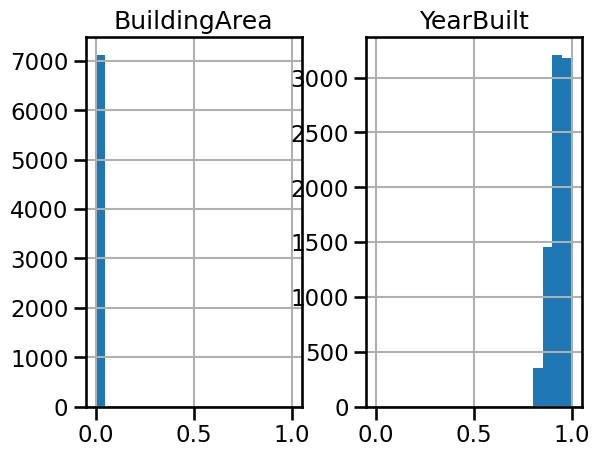

In [22]:
# Antes
melb_scaled[['BuildingArea','YearBuilt']].hist(bins=20)

array([[<Axes: title={'center': 'BuildingArea'}>,
        <Axes: title={'center': 'YearBuilt'}>]], dtype=object)

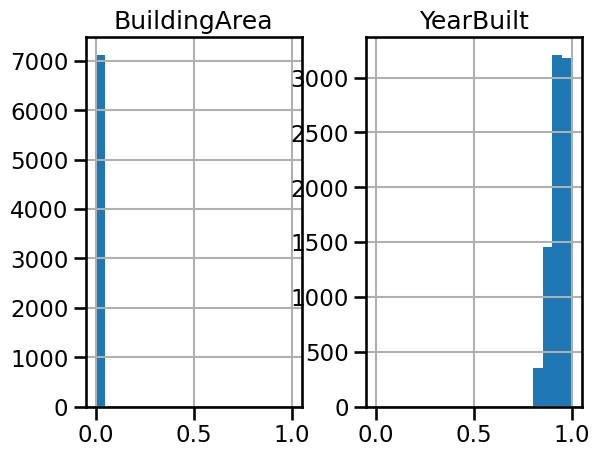

In [23]:
# Después
melb_scaled_knn[['BuildingArea','YearBuilt']].hist(bins=20)

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos?
2. Seleccione las primeras $2$ columnas de la matriz transformada para agregar como nuevas características al conjunto de datos. Realizar un gráfico de la componente principal 1 vs la componente principal 2 (pca1-pca2).
3. Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

**Ejemplo de código para este problema**

In [ ]:
## Ejemplo pequeño, tienen que extenderlo a su DataFrame procesada
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

## Supongamos solo estas variables
categorical_cols = ['Type', 'Regionname']
numerical_cols = ['Rooms', 'Distance']
new_columns = []

# Paso 1: codificamos las variables categóricas
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(melb_df[categorical_cols])
for col, col_values in zip(categorical_cols, encoder.categories_):
  for col_value in col_values:
    new_columns.append('{}={}'.format(col, col_value))
print("Matrix has shape {}, with columns: {}".format(X_cat.shape, new_columns))

# Paso 2: anexamos las variables numéricas
X = numpy.hstack([X_cat, melb_df[numerical_cols].values])
new_columns.extend(numerical_cols)
print("Matrix has shape {}, with columns: {}".format(X_cat.shape, new_columns))

# Paso 3: usamos las dos primeras componentes principales a nuestro conjunto de datos
pca = PCA(n_components=2)
pca_dummy_features = pca.fit_transform(X)
X_pca = numpy.hstack([X, pca_dummy_features])
new_columns.extend(['pca1', 'pca2'])

## Paso 4: rearmamos el datagframe (ver que al final tenemos las componentes principales)
processed_melb_df = pandas.DataFrame(data=X_pca, columns=new_columns)
processed_melb_df.head()

## Falta la parte de guardarlo en un archivo

Matrix has shape (13580, 11), with columns: ['Type=h', 'Type=t', 'Type=u', 'Regionname=Eastern Metropolitan', 'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan', 'Regionname=Northern Victoria', 'Regionname=South-Eastern Metropolitan', 'Regionname=Southern Metropolitan', 'Regionname=Western Metropolitan', 'Regionname=Western Victoria']
Matrix has shape (13580, 11), with columns: ['Type=h', 'Type=t', 'Type=u', 'Regionname=Eastern Metropolitan', 'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan', 'Regionname=Northern Victoria', 'Regionname=South-Eastern Metropolitan', 'Regionname=Southern Metropolitan', 'Regionname=Western Metropolitan', 'Regionname=Western Victoria', 'Rooms', 'Distance']


,Type=h,Type=t,Type=u,Regionname=Eastern Metropolitan,Regionname=Eastern Victoria,Regionname=Northern Metropolitan,Regionname=Northern Victoria,Regionname=South-Eastern Metropolitan,Regionname=Southern Metropolitan,Regionname=Western Metropolitan,Regionname=Western Victoria,Rooms,Distance,pca1,pca2
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.5,-7.669418,-0.292703
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.5,-7.669418,-0.292703
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,2.5,-7.620201,0.619633
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,2.5,-7.620201,0.619633
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,2.5,-7.570984,1.531969


## Ejercicio 4: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas y de imputación de datos faltantes
  2. Interpretación de las columnas presentes
  3. Todas las transofrmaciones realizadas
  4. Análisis breve de lo observado mediante PCA.

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
